<div style="background:linear-gradient(135deg,#0D2B55 0%,#1F497D 60%,#2E86C1 100%);padding:28px 32px;border-radius:10px;margin-bottom:18px"><h1 style="color:white;margin:0 0 6px 0;font-size:1.9em">Financial Risk Management and Engineering &middot; Session 7: Liquidity Risk &amp; Operational Risk</h1><p style="color:#BDC3C7;margin:0;font-size:1.0em">Sprott School of Business · Carleton University · Summer 2026</p><p style="color:#85C1E9;margin:8px 0 0 0;font-size:0.9em">Amihud Illiquidity · Corwin&ndash;Schultz Spread · Liquidity-Adjusted VaR · Endogenous Liquidation Cost · Funding Ladder · LDA Op-Risk · Basel SMA</p></div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Setup &mdash; Source Material, Packages &amp; Environment Check</span><br><span style="color:#BDC3C7;font-size:0.93em">Run this first &middot; works on any recent Python 3.9+</span></div>

<div style="background:#0D2B45;border-left:5px solid #2E86C1;padding:13px 20px;border-radius:0 8px 8px 0;margin:10px 0"><span style="color:#7DB5D8;font-weight:bold">&#128218; Source material &nbsp;</span><span style="color:#B8D4E8;line-height:1.7">This session follows <b>Hull (2023), <i>Risk Management and Financial Institutions</i> (6th ed.): Ch. 20 (Operational Risk) &amp; Ch. 21 (Liquidity Risk)</b>; and <b>Jorion (2010), <i>Financial Risk Manager Handbook</i> (6th ed.): Ch. 25 (Operational Risk) &amp; Ch. 26 (Liquidity Risk)</b>.</span></div>

This notebook uses the standard scientific-Python stack. If you installed **[Anaconda](https://www.anaconda.com/download)** most of these are already present; otherwise install everything in one line (from a terminal, or prefix with `!` in a cell):

```
pip install yfinance pandas numpy matplotlib seaborn scipy
```

No installs allowed on your machine? **[Google Colab](https://colab.research.google.com)** runs this notebook free in the browser &mdash; upload the `.ipynb` and add a first cell with `!pip install yfinance pandas numpy matplotlib seaborn scipy`.

<div style="background:#0A2A1A;border-left:5px solid #1E8449;padding:12px 18px;border-radius:0 8px 8px 0;margin:10px 0"><span style="color:#52C97A;font-weight:bold">&#10003; Environment check &nbsp;</span><span style="color:#90D4A8;line-height:1.7">Run the cell below. Every line should print a version number. Anything marked <code>NOT INSTALLED</code> tells you exactly what to <code>pip install</code>, then <b>Kernel &rarr; Restart &amp; Run All</b>.</span></div>

In [1]:
import importlib, sys
print('Python', sys.version.split()[0], '\n')
for pkg in ['numpy', 'pandas', 'matplotlib', 'scipy', 'yfinance', 'seaborn']:
    try:
        m = importlib.import_module(pkg)
        print(f'  {pkg:13s} {getattr(m, "__version__", "ok")}')
    except Exception:
        print(f'  {pkg:13s} NOT INSTALLED  ->  pip install {pkg}')

Python 3.13.3 

  numpy         2.1.3
  pandas        2.2.3
  matplotlib    3.10.0
  scipy         1.17.1
  yfinance      0.2.55
  seaborn       0.13.2


<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> <b>When things break.</b> <b>Run cells top to bottom</b> &mdash; order matters. If results look wrong, <b>Kernel &rarr; Restart &amp; Run All</b>. Common errors: <code>ModuleNotFoundError</code> &rarr; <code>pip install &lt;name&gt;</code> then restart; <code>NameError</code> &rarr; you skipped the cell that defines it; <code>YFRateLimitError</code> &rarr; Yahoo throttled you, wait a minute &mdash; this notebook caches data in <code>notebook_data/</code> so a re-run works offline. Read the <b>last</b> line of a traceback first.</div>

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from IPython.display import display

plt.rcParams.update({
    'figure.figsize': (13, 5), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 12,
})

# ── Analysis window ────────────────────────────────────────────────────
START  = '2021-07-01'
END    = '2026-07-01'
RF_ANNUAL = 0.04          # risk-free rate (annual)
RF_DAILY  = RF_ANNUAL / 252

# ── Stock universe (differing liquidity) ───────────────────────────────
# AAPL  – mega-cap, highly liquid
# JPM   – large-cap financial
# BKD   – small-cap (Brookdale Senior Living) — lower liquidity
# CVNA  – mid-cap, higher volatility/liquidity variation
TICKERS = ['AAPL', 'JPM', 'BKD', 'CVNA']

# ── Reproducibility ────────────────────────────────────────────────────
RNG = np.random.default_rng(42)

print('Libraries loaded. Analysis period:', START, '→', END)
print('Universe:', TICKERS)


Libraries loaded. Analysis period: 2021-07-01 → 2026-07-01
Universe: ['AAPL', 'JPM', 'BKD', 'CVNA']


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 1 — Data Download &amp; OHLCV Preparation</span><br><span style="color:#BDC3C7;font-size:0.93em">Slide 2 · Full OHLCV required for Amihud and Corwin–Schultz estimators</span></div>

In [3]:
import os, time

CACHE_FILE = (
    '/Users/yuriyzabolotnyuk/Library/CloudStorage/OneDrive-CarletonUniversity/'
    'Aarhus/Financial Risk Management 2026/Session Materials/'
    'notebook_data/Session_07_data.csv'
)

def download_with_retry(tickers, start, end, retries=3, delay=5):
    """Download OHLCV with up to `retries` attempts."""
    for attempt in range(1, retries + 1):
        try:
            raw = yf.download(
                tickers, start=start, end=end,
                auto_adjust=False, progress=False
            )
            if raw.empty:
                raise ValueError('Empty DataFrame returned.')
            return raw
        except Exception as e:
            print(f'Attempt {attempt} failed: {e}')
            if attempt < retries:
                time.sleep(delay)
    raise RuntimeError('All download attempts failed.')

# ── Cache logic ────────────────────────────────────────────────────────
if os.path.exists(CACHE_FILE):
    print('Loading from cache:', CACHE_FILE)
    raw = pd.read_csv(CACHE_FILE, header=[0,1], index_col=0, parse_dates=True)
else:
    print('Downloading from yfinance ...')
    raw = download_with_retry(TICKERS, START, END)
    os.makedirs(os.path.dirname(CACHE_FILE), exist_ok=True)
    raw.to_csv(CACHE_FILE)
    print('Saved to cache.')

print('Shape:', raw.shape)
raw.tail(3)


Loading from cache: /Users/yuriyzabolotnyuk/Library/CloudStorage/OneDrive-CarletonUniversity/Aarhus/Financial Risk Management 2026/Session Materials/notebook_data/Session_07_data.csv
Shape: (1254, 24)


Price        Adj Close                                     Close         \
Ticker            AAPL    BKD       CVNA         JPM        AAPL    BKD   
Date                                                                      
2026-06-26  283.779999  15.71  62.349998  329.049988  283.779999  15.71   
2026-06-29  281.739990  15.86  63.720001  329.390015  281.739990  15.86   
2026-06-30  289.359985  16.09  65.820000  327.329987  289.359985  16.09   

Price                                    High             ...        Low  \
Ticker           CVNA         JPM        AAPL        BKD  ...       CVNA   
Date                                                      ...              
2026-06-26  62.349998  329.049988  285.950012  15.830000  ...  61.849998   
2026-06-29  63.720001  329.390015  288.369995  16.000000  ...  63.220001   
2026-06-30  65.820000  327.329987  289.940002  16.309999  ...  62.369999   

Price                         Open                                   Volume  \
Ticker             JPM        AAPL    BKD       CVNA         JPM       AAPL   
Date                                                                          
2026-06-26  327.500000  275.000000  15.49  65.500000  336.000000  261775500   
2026-06-29  327.200012  286.730011  15.71  64.110001  328.279999   66427000   
2026-06-30  326.679993  281.170013  15.86  62.900002  328.890015   65100200   

Price                                     
Ticker           BKD      CVNA       JPM  
Date                                      
2026-06-26  17182000  36196500  17640900  
2026-06-29   4993400  13109500   7981800  
2026-06-30   4089200   8659000   8080100  

[3 rows x 24 columns]

In [4]:
# ── Extract per-field DataFrames ──────────────────────────────────────
# Handle both MultiIndex (multi-ticker) and flat (single-ticker) columns
def extract_field(raw, field):
    """Return a DataFrame with one column per ticker for `field`."""
    if isinstance(raw.columns, pd.MultiIndex):
        return raw[field]
    else:
        return raw[[field]]

close  = extract_field(raw, 'Close')
high   = extract_field(raw, 'High')
low    = extract_field(raw, 'Low')
volume = extract_field(raw, 'Volume')

# Drop rows where ALL tickers have NaN (e.g. weekends in cache)
close  = close.dropna(how='all')
high   = high.loc[close.index]
low    = low.loc[close.index]
volume = volume.loc[close.index]

# Daily log returns
returns = np.log(close / close.shift(1)).dropna()

print('Close shape:', close.shape)
print('Date range:', close.index[0].date(), '→', close.index[-1].date())
display(close.tail(3))


Close shape: (1254, 4)
Date range: 2021-07-01 → 2026-06-30


Ticker,AAPL,BKD,CVNA,JPM
Date,,,,
2026-06-26,283.779999,15.71,62.349998,329.049988
2026-06-29,281.739990,15.86,63.720001,329.390015
2026-06-30,289.359985,16.09,65.820000,327.329987


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 2 — Liquidity Risk: Amihud Illiquidity Ratio</span><br><span style="color:#BDC3C7;font-size:0.93em">Slides 3–5 · Market microstructure · Price impact of trading</span></div>

## Amihud (2002) Illiquidity Ratio

The Amihud illiquidity ratio measures how much prices move per dollar of volume traded — a proxy for **price impact** (Kyle's lambda).

$$\text{ILLIQ}_t = \frac{|r_t|}{D_t}$$

where $r_t$ is the daily log return and $D_t$ is dollar volume ($\text{Close}_t \times \text{Volume}_t$).  A higher ratio means a small trade moves the price more — **less liquid**.

Time-series average:
$$\overline{\text{ILLIQ}} = \frac{1}{T}\sum_{t=1}^{T} \frac{|r_t|}{D_t}$$

Amihud showed that **illiquid stocks earn an illiquidity premium** — investors demand extra return to hold assets that are costly to trade quickly.

> **Reference:** Amihud, Y. (2002). Illiquidity and stock returns: Cross-section and time-series effects. *Journal of Financial Markets*, 5(1), 31–56.

In [ ]:
# ── Amihud illiquidity ratio ──────────────────────────────────────────
dollar_vol = close.loc[returns.index] * volume.loc[returns.index]  # D_t
abs_ret    = returns.abs()                                           # |r_t|

# Replace zero dollar volume to avoid division errors
dollar_vol = dollar_vol.replace(0, np.nan)

illiq_daily = (abs_ret / dollar_vol) * 1e9   # scale ×10^6 for readability

# Mean Amihud ratio per stock
amihud_mean = illiq_daily.mean()
print('Mean Amihud Illiquidity (×10⁻9 per $ volume):')
for tk in amihud_mean.index:
    print(f'  {tk:6s}: {amihud_mean[tk]:.4f}')


Mean Amihud Illiquidity (×10⁻⁶ per $ volume):
  AAPL  : 0.0010
  BKD   : 2.1188
  CVNA  : 0.1310
  JPM   : 0.0056


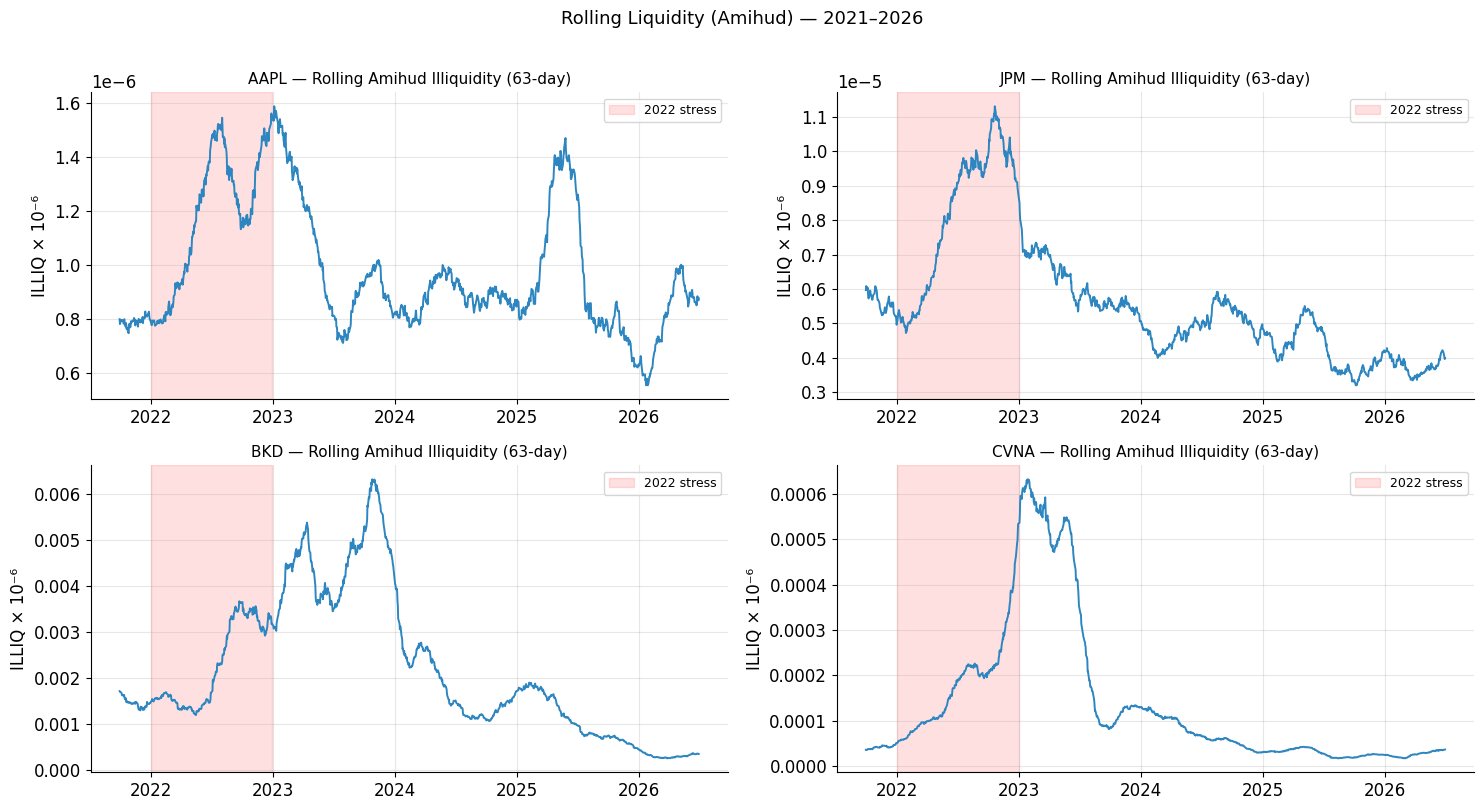


2022 average illiquidity vs. overall average:
  AAPL  : 2022 avg = 0.0000  |  full-period avg = 0.0000  |  ratio = 1.31x
  JPM   : 2022 avg = 0.0000  |  full-period avg = 0.0000  |  ratio = 1.51x
  BKD   : 2022 avg = 0.0025  |  full-period avg = 0.0021  |  ratio = 1.16x
  CVNA  : 2022 avg = 0.0003  |  full-period avg = 0.0001  |  ratio = 1.97x


In [6]:
# ── Rolling 63-day (≈ quarterly) Amihud ratio ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharey=False)
axes = axes.flatten()

for i, tk in enumerate(TICKERS):
    roll = illiq_daily[tk].rolling(63).mean()
    axes[i].plot(roll.index, roll.values, color='#2E86C1', lw=1.4)
    axes[i].set_title(f'{tk} — Rolling Amihud Illiquidity (63-day)', fontsize=11)
    axes[i].set_ylabel('ILLIQ × 10⁻⁶')
    axes[i].axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
                   alpha=0.12, color='red', label='2022 stress')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].legend(fontsize=9)

plt.suptitle('Rolling Liquidity (Amihud) — 2021–2026', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\n2022 average illiquidity vs. overall average:')
for tk in TICKERS:
    yr2022 = illiq_daily[tk]['2022'].mean()
    overall = illiq_daily[tk].mean()
    print(f'  {tk:6s}: 2022 avg = {yr2022:.4f}  |  full-period avg = {overall:.4f}  '
          f'|  ratio = {yr2022/overall:.2f}x')


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 3 — Corwin–Schultz High-Low Bid-Ask Spread Estimator</span><br><span style="color:#BDC3C7;font-size:0.93em">Slides 6–7 · OHLC-based transaction cost proxy</span></div>

## Corwin–Schultz (2012) Spread Estimator

The **Corwin–Schultz** estimator recovers the effective bid-ask spread from daily high and low prices — no tick data required.

**Intuition:** The high-to-low range reflects both volatility and the bid-ask bounce. Across two consecutive days, the extra range attributable to the spread can be isolated.

**Key formulas:**

$$\beta = \left[\ln\!\left(\frac{H_t}{L_t}\right)\right]^2 + \left[\ln\!\left(\frac{H_{t+1}}{L_{t+1}}\right)\right]^2$$

$$\gamma = \left[\ln\!\left(\frac{\max(H_t, H_{t+1})}{\min(L_t, L_{t+1})}\right)\right]^2$$

$$\alpha = \frac{\sqrt{2\beta} - \sqrt{\beta}}{3 - 2\sqrt{2}} - \sqrt{\frac{\gamma}{3 - 2\sqrt{2}}}$$

$$S = \frac{2(e^{\alpha} - 1)}{1 + e^{\alpha}} \qquad (\text{set } S=0 \text{ if } \alpha < 0)$$

The spread $S$ is expressed as a **fraction of the mid-price** (relative spread).

> **Reference:** Corwin, S. A., & Schultz, P. (2012). A simple way to estimate bid-ask spreads from daily high and low prices. *Journal of Finance*, 67(2), 719–760.

In [7]:
def corwin_schultz_spread(high: pd.Series, low: pd.Series) -> pd.Series:
    """Corwin–Schultz (2012) bid-ask spread estimator from daily High/Low."""
    h = high.values.astype(float)
    l = low.values.astype(float)
    # Two-day high/low
    h2 = np.maximum(h[:-1], h[1:])
    l2 = np.minimum(l[:-1], l[1:])
    # beta: sum of squared log ranges for consecutive days
    beta = (np.log(h[:-1] / l[:-1]))**2 + (np.log(h[1:] / l[1:]))**2
    # gamma: squared log range over two-day window
    gamma = (np.log(h2 / l2))**2
    # alpha
    sqrt2 = np.sqrt(2)
    denom = 3 - 2 * sqrt2
    alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / denom - np.sqrt(gamma / denom)
    # Spread (set negative estimates to 0)
    spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))
    spread = np.where(alpha < 0, 0.0, spread)
    # Align to index (one observation per pair of days → use second day's date)
    idx = high.index[1:]
    return pd.Series(spread, index=idx, name='CS_spread')

# Compute CS spread for each ticker
cs_spreads = {}
for tk in TICKERS:
    cs_spreads[tk] = corwin_schultz_spread(high[tk], low[tk])

cs_df = pd.DataFrame(cs_spreads)

print('Mean Corwin–Schultz spread (relative, bps):')
for tk in TICKERS:
    mean_bps = cs_df[tk].mean() * 1e4
    print(f'  {tk:6s}: {mean_bps:.2f} bps')


Mean Corwin–Schultz spread (relative, bps):
  AAPL  : 43.91 bps
  JPM   : 43.53 bps
  BKD   : 96.05 bps
  CVNA  : 174.86 bps


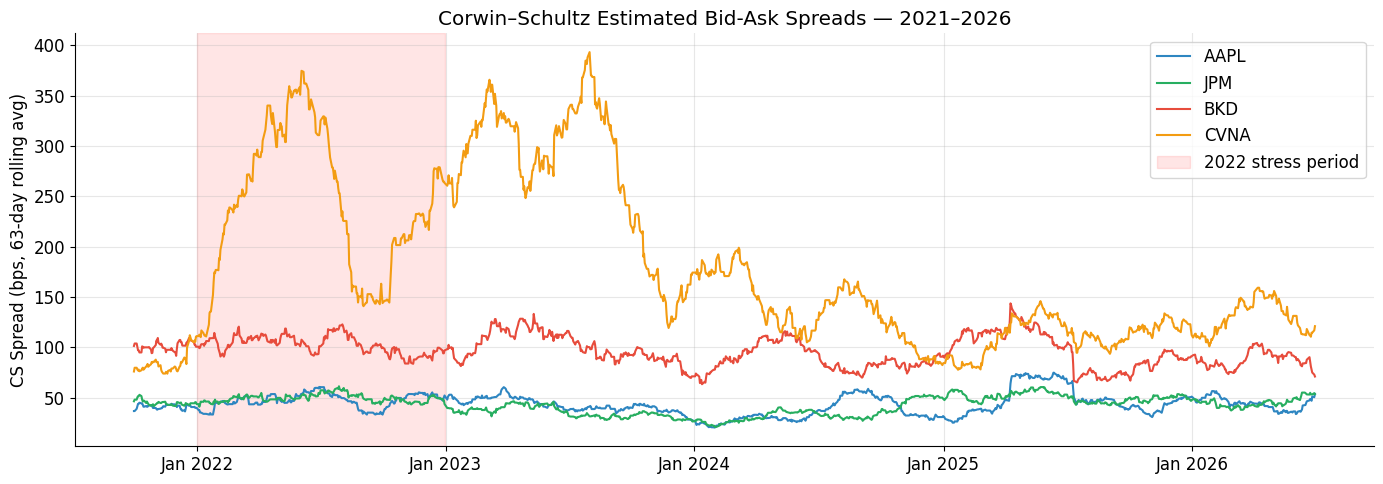

In [8]:
# ── Rolling 63-day average CS spread ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors = {'AAPL': '#2E86C1', 'JPM': '#27AE60', 'BKD': '#E74C3C', 'CVNA': '#F39C12'}
for tk in TICKERS:
    roll = cs_df[tk].rolling(63).mean() * 1e4  # bps
    ax.plot(roll.index, roll, label=tk, color=colors.get(tk), lw=1.5)

ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.10, color='red', label='2022 stress period')
ax.set_ylabel('CS Spread (bps, 63-day rolling avg)')
ax.set_title('Corwin–Schultz Estimated Bid-Ask Spreads — 2021–2026')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.show()


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 4 — Liquidity-Adjusted VaR (LVaR)</span><br><span style="color:#BDC3C7;font-size:0.93em">Slides 8–9 · Incorporating liquidation cost into market-risk VaR</span></div>

## Liquidity-Adjusted Value-at-Risk

Standard **VaR** measures the loss from adverse price moves but **ignores the cost of unwinding the position**. When markets are stressed and spreads widen, liquidation cost can materially exceed the VaR itself.

### Bangia et al. (1999) exogenous-spread LVaR

For a position of $V$ dollars in a stock with relative spread $S$ (bid-ask / mid):

$$\text{LVaR} = \text{VaR} + \text{LC}$$

$$\text{LC} = \frac{1}{2} \cdot V \cdot S$$

where $S$ is the effective spread (often taken as mean + $k$ standard deviations for stressed conditions).

**Parametric VaR** at confidence $c$ for a 1-day horizon:

$$\text{VaR}_{c} = V \cdot z_c \cdot \hat{\sigma}$$

where $z_c = \Phi^{-1}(c)$ and $\hat{\sigma}$ is the daily return volatility.

$$\text{LVaR}_{c} = V \cdot z_c \cdot \hat{\sigma} + \frac{1}{2} V \cdot S$$

> **Reference:** Jorion, P. (2010). *Financial Risk Manager Handbook*, 6th ed. Wiley, Chapter 14 (Liquidity Risk).

In [9]:
# ── Parametric LVaR for each ticker ──────────────────────────────────
POSITION_VALUE = 1_000_000   # $1 M position per stock
CONFIDENCE     = 0.99        # 99 % VaR
z_c = stats.norm.ppf(CONFIDENCE)

print(f'Position: ${POSITION_VALUE:,.0f}  |  Confidence: {CONFIDENCE:.0%}  |  z = {z_c:.4f}\n')
print(f'{'Ticker':>8}  {'σ_daily':>10}  {'VaR 99%':>12}  '
      f'{'Mean Spread':>14}  {'Liq Cost':>12}  {'LVaR 99%':>12}  {'LC/VaR':>8}')
print('-' * 95)

lvars = {}
for tk in TICKERS:
    sigma   = returns[tk].std()
    var_99  = POSITION_VALUE * z_c * sigma
    # Use mean CS spread for normal conditions; stressed = mean + 1σ
    s_mean  = cs_df[tk].mean()
    s_stressed = s_mean + cs_df[tk].std()   # one-sigma stressed spread
    lc      = 0.5 * POSITION_VALUE * s_stressed
    lvar    = var_99 + lc
    lvars[tk] = {'sigma': sigma, 'VaR': var_99, 'spread': s_stressed,
                 'LC': lc, 'LVaR': lvar}
    print(f'{tk:>8}  {sigma:>10.4f}  ${var_99:>11,.0f}  '
          f'{s_stressed*1e4:>11.1f}bps  ${lc:>11,.0f}  ${lvar:>11,.0f}  '
          f'{lc/var_99:>7.2%}')


Position: $1,000,000  |  Confidence: 99%  |  z = 2.3263

  Ticker     σ_daily       VaR 99%     Mean Spread      Liq Cost      LVaR 99%    LC/VaR
-----------------------------------------------------------------------------------------------
    AAPL      0.0174  $     40,495        105.3bps  $      5,264  $     45,759   13.00%
     JPM      0.0155  $     35,969        100.4bps  $      5,022  $     40,991   13.96%
     BKD      0.0334  $     77,627        213.3bps  $     10,666  $     88,293   13.74%
    CVNA      0.0689  $    160,366        440.3bps  $     22,013  $    182,379   13.73%


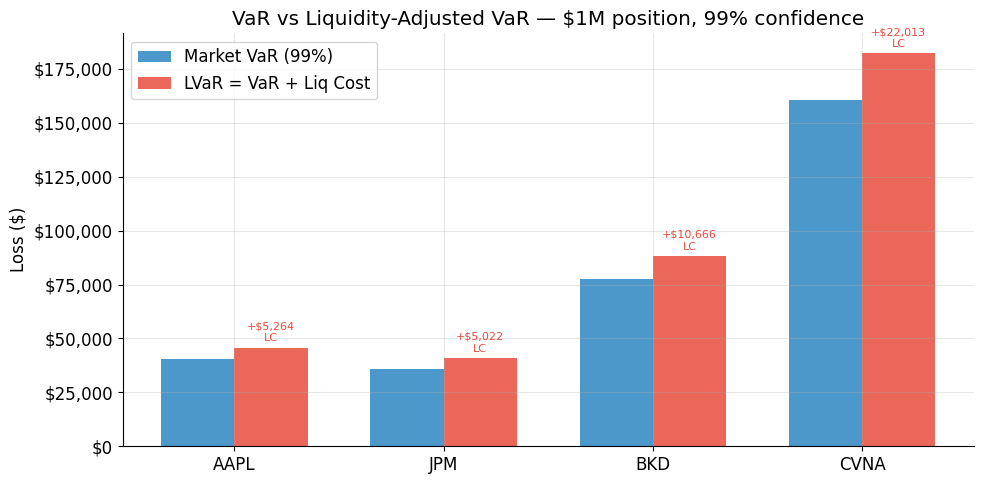

In [10]:
# ── Bar chart: VaR vs LVaR ────────────────────────────────────────────
tks = list(lvars.keys())
var_vals  = [lvars[tk]['VaR']  for tk in tks]
lc_vals   = [lvars[tk]['LC']   for tk in tks]
x = np.arange(len(tks))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, var_vals, w, label='Market VaR (99%)', color='#2E86C1', alpha=0.85)
bars2 = ax.bar(x + w/2, [v + l for v, l in zip(var_vals, lc_vals)], w,
               label='LVaR = VaR + Liq Cost', color='#E74C3C', alpha=0.85)
# Liq cost annotation
for j, tk in enumerate(tks):
    lc = lc_vals[j]
    ax.text(x[j] + w/2, lvars[tk]['LVaR'] + 2000, f'+${lc:,.0f}\nLC',
            ha='center', va='bottom', fontsize=8, color='#E74C3C')

ax.set_xticks(x); ax.set_xticklabels(tks)
ax.set_ylabel('Loss ($)')
ax.set_title(f'VaR vs Liquidity-Adjusted VaR — $1M position, 99% confidence')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:,.0f}'))
plt.tight_layout()
plt.show()


<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Beyond the half-spread: endogenous liquidation cost &amp; days-to-liquidate</span><br><span style="color:#BDC3C7;font-size:0.93em">Market impact · participation limits · the Almgren&ndash;Chriss timing trade-off</span></div>

The Bangia LVaR above charges a **fixed half-spread** and assumes you exit in **one day**. That is fine for a retail-sized position, but an institutional block breaks both assumptions:

- **Trading moves the price (endogenous impact).** The more you push through per day, the worse the fills. A standard *square-root law* sets the per-day impact at $\eta\,\sigma\sqrt{x}$, where $x$ is your share of daily volume.
- **You cannot exit in a day.** A participation cap (say 20% of average daily volume, ADV) sets a **days-to-liquidate** floor, $T \ge V / (p_{\max}\cdot \text{ADV}^{\$})$.
- **A slow unwind carries timing risk.** While you bleed the block out over $T$ days, the residual position is still exposed. For a linear unwind the execution-shortfall risk grows like $\sigma\sqrt{T/3}$.

Putting the pieces together (an Almgren&ndash;Chriss-style decomposition):

$$\text{Endogenous LVaR} \;=\; \underbrace{\tfrac12 V S}_{\text{spread}} \;+\; \underbrace{V\,\eta\,\sigma\sqrt{x}}_{\text{market impact}} \;+\; \underbrace{z_c\,\sigma\,V\sqrt{T/3}}_{\text{timing risk}}$$

Impact **falls** as you unwind more slowly (smaller $x$); timing risk **rises**. The two trade off, and there is a cost-minimising horizon.

> **References:** Almgren, R. &amp; Chriss, N. (2001). Optimal execution of portfolio transactions. *Journal of Risk*, 3(2). · Basel FRTB **liquidity horizons** (10/20/40/60/120 days) apply the same idea in the regulatory capital rule.

In [11]:
# ── Endogenous liquidation cost + days-to-liquidate ──────────────────────────
# Bangia's LC assumes a FIXED spread and a one-day exit. For an institutional
# block, unwinding (i) moves the price (endogenous impact) and (ii) takes days,
# over which the residual position stays at risk. We add a square-root impact
# law and the timing risk of a linear unwind, then compare to the half-spread.

BLOCK      = 200_000_000    # $200M institutional position (same block in each name)
PARTIC_MAX = 0.20           # never trade more than 20% of a day's volume
ETA        = 1.0            # square-root market-impact coefficient
z_liq      = stats.norm.ppf(CONFIDENCE)

# Average daily dollar volume over the last 252 trading days ($/day)
adv_dollar = (close * volume).tail(252).mean()

print(f'Block per name: ${BLOCK:,.0f}   participation cap: {PARTIC_MAX:.0%} of ADV   '
      f'confidence: {CONFIDENCE:.0%}\n')
hdr = (f"{'Ticker':>7}  {'ADV ($/day)':>16}  {'Days':>5}  {'Half-spread':>13}  "
       f"{'Impact':>13}  {'Timing risk':>13}  {'Endo-LVaR':>13}")
print(hdr); print('-'*len(hdr))

endo = {}
for tk in TICKERS:
    sigma = returns[tk].std()
    hs    = 0.5 * cs_df[tk].mean()              # half-spread (relative)
    advd  = adv_dollar[tk]
    T     = max(1.0, np.ceil(BLOCK / (PARTIC_MAX * advd)))   # days to unwind at the cap
    x     = (BLOCK / advd) / T                  # realised daily participation
    spread_cost = BLOCK * hs
    impact      = BLOCK * ETA * sigma * np.sqrt(x)           # square-root law
    timing      = z_liq * sigma * BLOCK * np.sqrt(T / 3.0)   # linear-unwind timing risk
    endo_lvar   = spread_cost + impact + timing
    endo[tk] = dict(advd=advd, T=T, spread=spread_cost, impact=impact,
                    timing=timing, lvar=endo_lvar)
    print(f'{tk:>7}  ${advd:>15,.0f}  {int(T):>5}  ${spread_cost:>12,.0f}  '
          f'${impact:>12,.0f}  ${timing:>12,.0f}  ${endo_lvar:>12,.0f}')

print('\nDays-to-liquidate is where the risk lives. For AAPL/JPM/CVNA the block')
print('clears in a day and the half-spread dominates; for BKD it takes weeks, and')
print('the TIMING risk of holding the residual position dwarfs the spread the')
print('Bangia LVaR would have charged. Same dollar block, very different liquidity.')

Block per name: $200,000,000   participation cap: 20% of ADV   confidence: 99%

 Ticker       ADV ($/day)   Days    Half-spread         Impact    Timing risk      Endo-LVaR
--------------------------------------------------------------------------------------------
   AAPL  $ 13,132,926,860      1  $     439,146  $     429,628  $   4,675,979  $   5,544,753
    JPM  $  2,827,137,540      1  $     435,261  $     822,482  $   4,153,352  $   5,411,095
    BKD  $     44,617,278     23  $     960,500  $   2,946,237  $  42,987,878  $  46,894,615
   CVNA  $  1,207,298,851      1  $   1,748,563  $   5,611,436  $  18,517,419  $  25,877,418

Days-to-liquidate is where the risk lives. For AAPL/JPM/CVNA the block
clears in a day and the half-spread dominates; for BKD it takes weeks, and
the TIMING risk of holding the residual position dwarfs the spread the
Bangia LVaR would have charged. Same dollar block, very different liquidity.


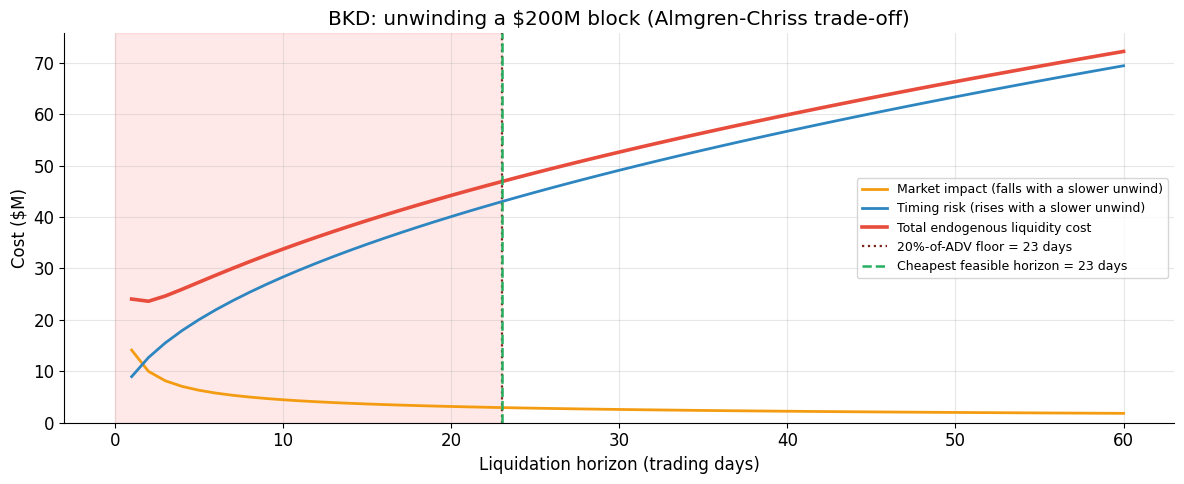

Shaded band = infeasible: exiting faster than 23 days needs > 20% of daily volume.
The naive Bangia half-spread cost here is just $960,500 - a small
fraction of the $46,894,615 it actually costs to get out of BKD.


In [12]:
# ── The liquidation trade-off: fast unwind (impact) vs slow unwind (timing) ──
# For the illiquid name, sweep the liquidation horizon and plot the two costs
# that pull in opposite directions. Their sum is U-shaped: the Almgren-Chriss
# efficient horizon sits at the bottom, subject to the participation-cap floor.
tk    = 'BKD'
sigma = returns[tk].std()
hs    = 0.5 * cs_df[tk].mean()
advd  = adv_dollar[tk]
spread_cost = BLOCK * hs

T_grid      = np.arange(1, 61)
x_grid      = (BLOCK / advd) / T_grid                    # daily participation
impact_grid = BLOCK * ETA * sigma * np.sqrt(x_grid)
timing_grid = z_liq * sigma * BLOCK * np.sqrt(T_grid / 3.0)
total_grid  = spread_cost + impact_grid + timing_grid

T_cap = int(np.ceil(BLOCK / (PARTIC_MAX * advd)))        # fastest feasible unwind
feas  = T_grid >= T_cap
T_opt = T_grid[feas][np.argmin(total_grid[feas])]        # cheapest feasible horizon

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(T_grid, impact_grid/1e6, color='#F39C12', lw=2, label='Market impact (falls with a slower unwind)')
ax.plot(T_grid, timing_grid/1e6, color='#2E86C1', lw=2, label='Timing risk (rises with a slower unwind)')
ax.plot(T_grid, total_grid/1e6,  color='#E74C3C', lw=2.6, label='Total endogenous liquidity cost')
ax.axvspan(0, T_cap, alpha=0.09, color='red')
ax.axvline(T_cap, color='#7B241C', ls=':',  lw=1.6, label=f'{PARTIC_MAX:.0%}-of-ADV floor = {T_cap} days')
ax.axvline(T_opt, color='#27AE60', ls='--', lw=1.8, label=f'Cheapest feasible horizon = {T_opt} days')
ax.set_xlabel('Liquidation horizon (trading days)')
ax.set_ylabel('Cost ($M)')
ax.set_title(f'{tk}: unwinding a ${BLOCK/1e6:.0f}M block (Almgren-Chriss trade-off)')
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Shaded band = infeasible: exiting faster than {T_cap} days needs > {PARTIC_MAX:.0%} of daily volume.')
print(f'The naive Bangia half-spread cost here is just ${spread_cost:,.0f} - a small')
print(f'fraction of the ${total_grid[feas].min():,.0f} it actually costs to get out of {tk}.')

<div style="border-left:5px solid #F39C12;background:#2D2000;padding:12px 18px;border-radius:0 6px 6px 0;margin:14px 0"><b style="color:#F7DC6F;font-size:1.05em">Basel III Regulatory Liquidity Ratios</b><br><br><b style="color:#F7DC6F">Liquidity Coverage Ratio (LCR)</b><br><span style="color:#FAD7A0">$$\text{LCR} = \frac{\text{High-Quality Liquid Assets (HQLA)}}{\text{Net Cash Outflows over 30 days}} \geq 100\%$$Ensures a bank can survive a 30-day liquidity stress scenario using its buffer of HQLA (Level 1: central bank reserves/govies; Level 2: covered bonds, equities).</span><br><br><b style="color:#F7DC6F">Net Stable Funding Ratio (NSFR)</b><br><span style="color:#FAD7A0">$$\text{NSFR} = \frac{\text{Available Stable Funding (ASF)}}{\text{Required Stable Funding (RSF)}} \geq 100\%$$Requires banks to fund illiquid assets with stable, long-term liabilities — addresses structural (12-month) funding mismatches. ASF includes equity, long-term debt; RSF scales with the illiquidity of each asset class.</span><br><br><span style="color:#F0B27A;font-size:0.9em">Reference: Hull, J. C. (2023). <i>Risk Management and Financial Institutions</i>, 6th ed., Ch. 24 (Liquidity Risk).</span></div>

<div style="background:#0D2B45;border-left:6px solid #27AE60;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Block 5 &middot; Operational Risk: Loss Distribution Approach (LDA) &amp; Basel SMA</span><br><span style="color:#BDC3C7;font-size:0.93em">Slides 10&ndash;13 · LDA 99.9% OpVaR (economic capital) · Standardised Approach (regulatory capital)</span></div>

## Operational Risk &middot; Loss Distribution Approach (LDA)

**Operational risk** (Basel definition): *the risk of loss resulting from inadequate or failed internal processes, people, systems, or external events* (including legal risk but excluding strategic/reputational risk).

### Loss Distribution Approach (LDA)

The LDA models **aggregate annual loss** $L$ as a **compound process**:

$$L = \sum_{i=1}^{N} X_i$$

| Component | Model | Parameters |
|-----------|-------|------------|
| Loss frequency $N$ | Poisson | $\lambda$ = expected number of loss events per year |
| Loss severity $X_i$ | Lognormal | $\mu$ = log-mean, $\sigma$ = log-std |

**Why Lognormal severity?** Operational losses are non-negative and right-skewed (single-event losses range from small process failures to catastrophic events; the fat right tail is the key risk driver).

The 99.9th percentile of $L$ is the **OpVaR**:

$$\text{OpVaR}_{99.9\%} = F_L^{-1}(0.999), \qquad \text{Economic capital} = \text{OpVaR}_{99.9\%} - \text{EL}$$

### From LDA to *regulatory* capital: AMA is gone, SMA is the rule

Under the old **Advanced Measurement Approach (AMA)** this simulated 99.9% OpVaR *was* the Basel regulatory charge. **The AMA was withdrawn in the Basel III finalization (2017, phased in from January 2023):** modelled 99.9% quantiles proved unstable and non-comparable across banks (tiny changes in $\sigma$ or the severity fit swing the number wildly, as we show below).

It is replaced by the single **Standardised Measurement Approach (SMA)**, a formula-based charge computed in a later cell:

$$\text{Capital}_{\text{SMA}} = \text{BIC} \times \text{ILM}$$

where the **Business Indicator Component (BIC)** scales with the size of the bank's income and the **Internal Loss Multiplier (ILM)** tilts it up or down for the bank's own 10-year loss history. **The LDA still matters** for *internal* economic capital, insurance pricing, stress and scenario analysis, and as the intuition behind the loss multiplier.

> **References:** Jorion, P. (2010). *Financial Risk Manager Handbook*, 6th ed., Ch. 25. · BCBS (2017). *Basel III: Finalising post-crisis reforms* &mdash; Operational risk (the Standardised Approach).

In [15]:
# ── LDA Parameters (illustrative — calibrated to mid-size bank) ──────
LAM     = 12      # Poisson: expected number of operational loss events per year
MU_LN   = 13.5    # Lognormal log-mean  (~$730k median single-event loss)
SIGMA_LN = 1.8    # Lognormal log-std   (heavy tail)
N_SIMS  = 50_000  # Monte Carlo iterations

print(f'Frequency:  Poisson(λ={LAM})')
print(f'Severity:   Lognormal(μ={MU_LN}, σ={SIGMA_LN})')
print(f'  Median single loss: ${np.exp(MU_LN):,.0f}')
print(f'  Mean single loss:   ${np.exp(MU_LN + 0.5*SIGMA_LN**2):,.0f}')
print(f'Simulations: {N_SIMS:,}')

# ── Monte Carlo: aggregate annual loss ───────────────────────────────
aggregate_losses = np.zeros(N_SIMS)
for sim in range(N_SIMS):
    n_events = RNG.poisson(LAM)          # draw number of events this year
    if n_events > 0:
        losses = RNG.lognormal(MU_LN, SIGMA_LN, size=n_events)
        aggregate_losses[sim] = losses.sum()

# ── Summary statistics ───────────────────────────────────────────────
el       = aggregate_losses.mean()
op_var99   = np.percentile(aggregate_losses, 99.0)
op_var999  = np.percentile(aggregate_losses, 99.9)
capital_charge = op_var999 - el

print(f'\n--- Aggregate Annual Op-Loss Distribution (n={N_SIMS:,} sims) ---')
print(f'  Expected Loss (EL):         ${el:>15,.0f}')
print(f'  Median:                     ${np.median(aggregate_losses):>15,.0f}')
print(f'  99th percentile (OpVaR99):  ${op_var99:>15,.0f}')
print(f'  99.9th pct (OpVaR 99.9%):   ${op_var999:>15,.0f}')
print(f'  Basel Capital (VaR–EL):     ${capital_charge:>15,.0f}')


Frequency:  Poisson(λ=12)
Severity:   Lognormal(μ=13.5, σ=1.8)
  Median single loss: $729,416
  Mean single loss:   $3,685,807
Simulations: 50,000

--- Aggregate Annual Op-Loss Distribution (n=50,000 sims) ---
  Expected Loss (EL):         $     44,547,883
  Median:                     $     29,404,919
  99th percentile (OpVaR99):  $    254,739,897
  99.9th pct (OpVaR 99.9%):   $    704,487,096
  Basel Capital (VaR–EL):     $    659,939,213


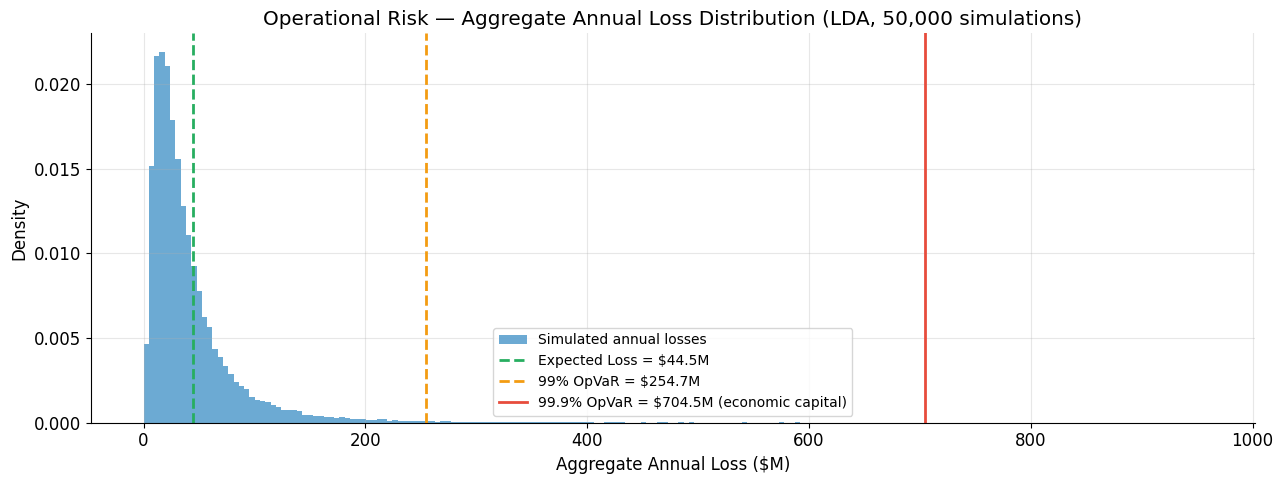

In [16]:
# ── Plot aggregate loss distribution ─────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Clip tail for plotting (99.95th pct)
plot_max = np.percentile(aggregate_losses, 99.95)
plot_data = aggregate_losses[aggregate_losses <= plot_max]

ax.hist(plot_data / 1e6, bins=200, density=True, color='#2E86C1',
        alpha=0.7, label='Simulated annual losses')

ax.axvline(el / 1e6, color='#27AE60', lw=2, ls='--',
           label=f'Expected Loss = ${el/1e6:.1f}M')
ax.axvline(op_var99 / 1e6, color='#F39C12', lw=2, ls='--',
           label=f'99% OpVaR = ${op_var99/1e6:.1f}M')
ax.axvline(op_var999 / 1e6, color='#E74C3C', lw=2, ls='-',
           label=f'99.9% OpVaR = ${op_var999/1e6:.1f}M (economic capital)')

ax.set_xlabel('Aggregate Annual Loss ($M)')
ax.set_ylabel('Density')
ax.set_title('Operational Risk — Aggregate Annual Loss Distribution (LDA, 50,000 simulations)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [17]:
# ── Fat-tailedness of aggregate loss distribution ────────────────────
from scipy.stats import kurtosis, skew

agg_kurt  = kurtosis(aggregate_losses, fisher=True)   # excess kurtosis
agg_skew  = skew(aggregate_losses)

print('Shape of the aggregate loss distribution:')
print(f'  Skewness (excess):       {agg_skew:>8.2f}  (Normal = 0)')
print(f'  Excess kurtosis:         {agg_kurt:>8.2f}  (Normal = 0, heavy tail > 0)')
print(f'  99.9%/99% ratio:         {op_var999/op_var99:>8.2f}  '
      f'(measures tail thickness above 99%)')
print(f'  99.9%/Mean ratio:        {op_var999/el:>8.2f}')
print()
print('Interpretation: fat tails mean the 99.9% Basel capital charge is substantially')
print('larger than what a Normal approximation would suggest.')

# Normal benchmark
mu_agg, sig_agg = aggregate_losses.mean(), aggregate_losses.std()
normal_var999 = mu_agg + stats.norm.ppf(0.999) * sig_agg
print(f'\n  Simulated 99.9% OpVaR:  ${op_var999:>14,.0f}')
print(f'  Normal approx 99.9% VaR: ${normal_var999:>13,.0f}')
print(f'  Underestimate if Normal: {(normal_var999 - op_var999)/op_var999:>8.1%}')


Shape of the aggregate loss distribution:
  Skewness (excess):          27.48  (Normal = 0)
  Excess kurtosis:          1666.92  (Normal = 0, heavy tail > 0)
  99.9%/99% ratio:             2.77  (measures tail thickness above 99%)
  99.9%/Mean ratio:           15.81

Interpretation: fat tails mean the 99.9% Basel capital charge is substantially
larger than what a Normal approximation would suggest.

  Simulated 99.9% OpVaR:  $   704,487,096
  Normal approx 99.9% VaR: $  266,342,941
  Underestimate if Normal:   -62.2%


<div style="background:#0D2B45;border-left:6px solid #F39C12;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.15em;font-weight:700;color:#F7DC6F">The current rule: Basel Standardised Approach (SMA)</span><br><span style="color:#BDC3C7;font-size:0.93em">Capital = BIC &times; ILM &middot; replaces the AMA the LDA above stood in for</span></div>

The fat-tail result above is *exactly why the AMA was retired*: the 99.9% capital number is enormously sensitive to the severity $\sigma$, which every bank estimated differently. The Basel III finalization replaced modelled capital with a formula every bank computes the same way:

$$\text{Capital}_{\text{SMA}} = \underbrace{\text{BIC}}_{\text{size, from income}} \times \underbrace{\text{ILM}}_{\text{own loss history}}, \qquad \text{ILM} = \ln\!\Big(e - 1 + \big(\tfrac{\text{LC}}{\text{BIC}}\big)^{0.8}\Big), \quad \text{LC} = 15 \times \overline{\text{annual loss}}$$

The **BIC** is a piecewise-marginal function of the Business Indicator (coefficients 12% / 15% / 18% across the €1bn and €30bn thresholds); the **ILM** nudges the charge above or below the size-implied level for the bank's own 10-year loss record. The cell below computes it for the same bank as the LDA, and shows how unstable the old 99.9% number was.

In [18]:
# ── Basel Standardised Approach (SMA): the CURRENT regulatory op-risk charge ──
# Capital = BIC x ILM   (BCBS 2017, effective Jan 2023; replaced the AMA above)
#   BIC = Business Indicator Component: piecewise-marginal on the Business
#         Indicator (BI ~ a bank's gross income proxy), coefficients 12/15/18%.
#   ILM = Internal Loss Multiplier: ln(e - 1 + (LC/BIC)^0.8), where the
#         Loss Component LC = 15 x average annual operational loss (10-yr).
# Thresholds are in EUR; we treat $ ~ EUR here for a clean illustration.

def business_indicator_component(BI):
    """Marginal-bucket BIC (EUR): 12% to 1bn, 15% 1-30bn, 18% above 30bn."""
    b1, b2 = 1e9, 30e9
    if BI <= b1:
        return 0.12 * BI
    if BI <= b2:
        return 0.12*b1 + 0.15*(BI - b1)
    return 0.12*b1 + 0.15*(b2 - b1) + 0.18*(BI - b2)

def internal_loss_multiplier(LC, BIC):
    return np.log(np.e - 1 + (LC / BIC)**0.8)

# --- Worked example: the same mid-size bank as the LDA above -----------------
BI          = 20e9                     # Business Indicator ~ $20bn (bucket 2)
avg_ann_loss = el                      # reuse the LDA expected annual loss
LC          = 15 * avg_ann_loss        # Basel Loss Component
BIC         = business_indicator_component(BI)
ILM         = internal_loss_multiplier(LC, BIC)
capital_sma = BIC * ILM

print('Basel SMA operational-risk capital')
print('-'*46)
print(f'  Business Indicator (BI):     ${BI:>16,.0f}')
print(f'  BIC (12/15/18% marginal):    ${BIC:>16,.0f}')
print(f'  Avg annual op loss (10-yr):  ${avg_ann_loss:>16,.0f}')
print(f'  Loss Component  LC = 15x:    ${LC:>16,.0f}')
print(f'  Internal Loss Multiplier:    {ILM:>17.3f}')
print(f'  SMA capital = BIC x ILM:     ${capital_sma:>16,.0f}')
print()
print(f'  Memo - LDA 99.9% OpVaR:      ${op_var999:>16,.0f}  (economic capital)')
print(f'  Memo - retired AMA charge:   the LDA number above WAS the rule pre-2023')
print()
print('Reading it: ILM > 1 means this bank\'s loss history is worse than a size-')
print('peer with average losses, so its charge is scaled UP; ILM < 1 scales it')
print('down. Unlike the AMA 99.9% quantile, the SMA is comparable bank-to-bank')
print('because it keys off observable income (BI), not a fitted tail.')

# --- Why the AMA was killed: the 99.9% quantile is unstable in sigma ---------
print('\nSensitivity of the LDA 99.9% OpVaR to the severity sigma (why AMA failed):')
for s in [1.6, 1.8, 2.0, 2.2]:
    sims = np.array([RNG.lognormal(MU_LN, s, size=RNG.poisson(LAM)).sum()
                     for _ in range(20_000)])
    print(f'  sigma={s:.1f}:  99.9% OpVaR = ${np.percentile(sims,99.9):>15,.0f}')

Basel SMA operational-risk capital
----------------------------------------------
  Business Indicator (BI):     $  20,000,000,000
  BIC (12/15/18% marginal):    $   2,970,000,000
  Avg annual op loss (10-yr):  $      44,547,883
  Loss Component  LC = 15x:    $     668,218,251
  Internal Loss Multiplier:                0.704
  SMA capital = BIC x ILM:     $   2,090,377,856

  Memo - LDA 99.9% OpVaR:      $     704,487,096  (economic capital)
  Memo - retired AMA charge:   the LDA number above WAS the rule pre-2023

Reading it: ILM > 1 means this bank's loss history is worse than a size-
peer with average losses, so its charge is scaled UP; ILM < 1 scales it
down. Unlike the AMA 99.9% quantile, the SMA is comparable bank-to-bank
because it keys off observable income (BI), not a fitted tail.

Sensitivity of the LDA 99.9% OpVaR to the severity sigma (why AMA failed):
  sigma=1.6:  99.9% OpVaR = $    354,532,926
  sigma=1.8:  99.9% OpVaR = $    667,026,526
  sigma=2.0:  99.9% OpVaR = $  1,

<div style="border-left:5px solid #E74C3C;background:#1A0000;padding:14px 20px;border-radius:0 6px 6px 0;margin:18px 0"><b style="color:#F1948A;font-size:1.1em">Major Operational Loss Events — Case Studies</b><br><br><table style="width:100%;border-collapse:collapse;color:#FDFEFE;font-size:0.93em"><thead><tr style="background:#2C1010;color:#F5B7B1"><th style="padding:6px 10px;text-align:left">Institution</th><th style="padding:6px 10px;text-align:left">Event</th><th style="padding:6px 10px;text-align:right">Loss</th><th style="padding:6px 10px;text-align:left">Basel Category</th><th style="padding:6px 10px;text-align:left">Key Lesson</th></tr></thead><tbody><tr style="border-bottom:1px solid #3D1111"><td style="padding:6px 10px"><b>Barings Bank</b> (1995)</td><td style="padding:6px 10px">Nick Leeson — unauthorized Nikkei futures speculation; concealed losses in error account 88888</td><td style="padding:6px 10px;text-align:right">~$1.3B</td><td style="padding:6px 10px">Internal Fraud / Execution Error</td><td style="padding:6px 10px">Dual control, segregation of trading &amp; back-office</td></tr><tr style="border-bottom:1px solid #3D1111"><td style="padding:6px 10px"><b>Société Générale / Kerviel</b> (2008)</td><td style="padding:6px 10px">Jérôme Kerviel built €50B unauthorized directional equity futures position; concealed with fictitious hedges</td><td style="padding:6px 10px;text-align:right">€4.9B</td><td style="padding:6px 10px">Internal Fraud</td><td style="padding:6px 10px">Limit monitoring, real-time P&amp;L reconciliation critical</td></tr><tr style="border-bottom:1px solid #3D1111"><td style="padding:6px 10px"><b>JPMorgan — London Whale</b> (2012)</td><td style="padding:6px 10px">Bruno Iksil's CIO unit accumulated $157B notional in illiquid CDS index positions; VaR model changed to mask breaches</td><td style="padding:6px 10px;text-align:right">~$6.2B</td><td style="padding:6px 10px">Execution Error / Model Failure</td><td style="padding:6px 10px">Model-change governance; liquidity &amp; concentration limits</td></tr><tr><td style="padding:6px 10px"><b>Silicon Valley Bank</b> (2023)</td><td style="padding:6px 10px">HTM bond portfolio exposed to interest-rate risk; unhedged duration mismatch; deposit concentration in tech sector led to bank run</td><td style="padding:6px 10px;text-align:right">~$1.8B recognized + closure</td><td style="padding:6px 10px">Risk Management Failure / Liquidity</td><td style="padding:6px 10px">ALM hedging, concentration risk, IRRBB management</td></tr></tbody></table></div>

<div style="background:linear-gradient(135deg,#1A3A1A 0%,#0D4D0D 100%);padding:20px 28px;border-radius:10px;margin:28px 0 10px 0;border:2px solid #27AE60"><h2 style="color:#82E0AA;margin:0 0 6px 0">Your Turn — Session 7 Exercises</h2><p style="color:#ABEBC6;margin:0;font-size:0.95em">Apply Amihud illiquidity, Corwin–Schultz spread, Liquidity-Adjusted VaR, and the Loss Distribution Approach to your own choices.</p></div>

## Part A — Amihud Illiquidity for Your Own Stock

1. Pick **one stock** not in our universe (e.g. a sector ETF, a foreign ADR, or a stock you follow personally). Download its OHLCV for 2021-07-01 to 2026-07-01.
2. Compute the **daily Amihud illiquidity ratio** (×10⁶).
3. Plot the 63-day rolling average and shade the 2022 stress period.
4. Compare its mean illiquidity to AAPL and BKD computed above — is your stock more or less liquid?

```python
# YOUR CODE HERE
YOUR_TICKER = 'MSFT'  # replace with your choice
```

## Part B — Corwin–Schultz Spread for Your Stock

Using the same downloaded data:
1. Compute the **daily Corwin–Schultz spread** using the `corwin_schultz_spread()` function defined above.
2. Report the mean spread in basis points.
3. Plot the 21-day rolling spread alongside AAPL for comparison.

```python
# YOUR CODE HERE
```

## Part C — Liquidity-Adjusted VaR

For your chosen stock with a **$500,000 position**:
1. Compute the **parametric 99% 1-day VaR** using historical return volatility.
2. Compute the **liquidity cost** using the stressed Corwin–Schultz spread (mean + 1 std deviation).
3. Report `VaR`, `LC`, `LVaR`, and the ratio `LC/VaR`.
4. Interpret: would you be comfortable using plain VaR for this stock, or is LVaR materially different?

```python
# YOUR CODE HERE
POSITION = 500_000
CONF     = 0.99
```

## Part D — Op-Risk LDA: Sensitivity Analysis

Re-run the Monte Carlo with your own parameter choices:

| Parameter | Your Choice | Interpretation |
|-----------|------------|----------------|
| λ | 5–30 | fewer vs. more frequent events |
| μ | 12–15 | smaller vs. larger median loss |
| σ | 1.0–2.5 | tighter vs. fatter severity tail |

1. Simulate 50,000 annual losses with your chosen parameters.
2. Report EL, 99% OpVaR, 99.9% OpVaR, and the excess-kurtosis.
3. Plot the distribution.
4. How sensitive is the 99.9% capital charge to σ (severity dispersion)? Try σ = 1.5 and σ = 2.5 and compare.

```python
# YOUR CODE HERE
MY_LAM    = 8      # your choice
MY_MU     = 14.0   # your choice
MY_SIGMA  = 2.0    # your choice
```